<a href="https://colab.research.google.com/github/mpakaBrice/Top-50-amazon/blob/main/amazon_top_50.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas_gbq as pq
from google.cloud import bigquery
#importation des differentes bibliotèque

In [5]:
df_amazon = pd.read_csv("/content/sample_data/top 50 vente amazon 2009- 2019 csv.csv")

In [6]:
df_amazon

,Name,Author,User Rating,Reviews,Price,Year,Genre
0,10-Day Green Smoothie Cleanse,JJ Smith,4.7,17350,8,2016,Non Fiction
1,11/22/63: A Novel,Stephen King,4.6,2052,22,2011,Fiction
2,12 Rules for Life: An Antidote to Chaos,Jordan B. Peterson,4.7,18979,15,2018,Non Fiction
3,1984 (Signet Classics),George Orwell,4.7,21424,6,2017,Fiction
4,"5,000 Awesome Facts (About Everything!) (Natio...",National Geographic Kids,4.8,7665,12,2019,Non Fiction
...,...,...,...,...,...,...,...
545,Wrecking Ball (Diary of a Wimpy Kid Book 14),Jeff Kinney,4.9,9413,8,2019,Fiction
546,You Are a Badass: How to Stop Doubting Your Gr...,Jen Sincero,4.7,14331,8,2016,Non Fiction
547,You Are a Badass: How to Stop Doubting Your Gr...,Jen Sincero,4.7,14331,8,2017,Non Fiction
548,You Are a Badass: How to Stop Doubting Your Gr...,Jen Sincero,4.7,14331,8,2018,Non Fiction


In [7]:
df_amazon.info() # Résumé du Dataframe

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 550 entries, 0 to 549
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Name         550 non-null    object 
 1   Author       550 non-null    object 
 2   User Rating  550 non-null    float64
 3   Reviews      550 non-null    int64  
 4   Price        550 non-null    int64  
 5   Year         550 non-null    int64  
 6   Genre        550 non-null    object 
dtypes: float64(1), int64(3), object(3)
memory usage: 30.2+ KB


In [8]:
df_unique = df_amazon.drop_duplicates(subset=['Name']) # On retire les doublons de noms pour avoir des statistiques par "Livre unique"

In [9]:
df_amazon

,Name,Author,User Rating,Reviews,Price,Year,Genre
0,10-Day Green Smoothie Cleanse,JJ Smith,4.7,17350,8,2016,Non Fiction
1,11/22/63: A Novel,Stephen King,4.6,2052,22,2011,Fiction
2,12 Rules for Life: An Antidote to Chaos,Jordan B. Peterson,4.7,18979,15,2018,Non Fiction
3,1984 (Signet Classics),George Orwell,4.7,21424,6,2017,Fiction
4,"5,000 Awesome Facts (About Everything!) (Natio...",National Geographic Kids,4.8,7665,12,2019,Non Fiction
...,...,...,...,...,...,...,...
545,Wrecking Ball (Diary of a Wimpy Kid Book 14),Jeff Kinney,4.9,9413,8,2019,Fiction
546,You Are a Badass: How to Stop Doubting Your Gr...,Jen Sincero,4.7,14331,8,2016,Non Fiction
547,You Are a Badass: How to Stop Doubting Your Gr...,Jen Sincero,4.7,14331,8,2017,Non Fiction
548,You Are a Badass: How to Stop Doubting Your Gr...,Jen Sincero,4.7,14331,8,2018,Non Fiction


In [11]:
# DF 1 : Pour les tendances annuelles (On garde les 550 lignes)
df_trends = df_amazon.copy()

# DF 2 : Pour les stats par livre (Prix moyen, Note, Genre)
# On ne veut pas qu'un livre qui est resté 5 ans dans le top 50 pèse 5 fois plus dans la moyenne.
df_books = df_amazon.drop_duplicates(subset=['Name', 'Author']).copy()

print(f"Nombre de livres uniques analysés : {len(df_books)}")

Nombre de livres uniques analysés : 351


In [12]:
# On remplace 0 par NaN pour ne pas fausser le calcul de la médiane
df_books['Price'] = df_books['Price'].replace(0, np.nan)

# On remplace les NaN par la médiane du prix de CHAQUE genre
df_books['Price'] = df_amazon['Price'].fillna(
    df_books.groupby('Genre')['Price'].transform('median')
)

print("Prix à 0$ corrigés avec succès.")

Prix à 0$ corrigés avec succès.


In [13]:
# Nettoyage des espaces blancs inutiles
df_books['Author'] = df_books['Author'].str.strip()

# Correction manuelle des doublons connus (ex: J.K. Rowling)
corrections = {
    'George R. R. Martin': 'George R.R. Martin',
    'J. K. Rowling': 'J.K. Rowling',
    'E L James': 'E.L. James'
}
df_books['Author'] = df_books['Author'].replace(corrections)

print(f"Nombre d'auteurs uniques après nettoyage : {df_books['Author'].nunique()}")

Nombre d'auteurs uniques après nettoyage : 246


In [14]:
df_yearly = df_amazon.copy() # Pour les graphiques par année
df_unique_books = df_amazon.drop_duplicates(subset=['Name', 'Author']) # Pour les corrélations Prix/Note
df_amazon

,Name,Author,User Rating,Reviews,Price,Year,Genre
0,10-Day Green Smoothie Cleanse,JJ Smith,4.7,17350,8,2016,Non Fiction
1,11/22/63: A Novel,Stephen King,4.6,2052,22,2011,Fiction
2,12 Rules for Life: An Antidote to Chaos,Jordan B. Peterson,4.7,18979,15,2018,Non Fiction
3,1984 (Signet Classics),George Orwell,4.7,21424,6,2017,Fiction
4,"5,000 Awesome Facts (About Everything!) (Natio...",National Geographic Kids,4.8,7665,12,2019,Non Fiction
...,...,...,...,...,...,...,...
545,Wrecking Ball (Diary of a Wimpy Kid Book 14),Jeff Kinney,4.9,9413,8,2019,Fiction
546,You Are a Badass: How to Stop Doubting Your Gr...,Jen Sincero,4.7,14331,8,2016,Non Fiction
547,You Are a Badass: How to Stop Doubting Your Gr...,Jen Sincero,4.7,14331,8,2017,Non Fiction
548,You Are a Badass: How to Stop Doubting Your Gr...,Jen Sincero,4.7,14331,8,2018,Non Fiction


In [15]:
df_amazon.describe()

,User Rating,Reviews,Price,Year
count,550.000000,550.000000,550.000000,550.000000
mean,4.618364,11953.281818,13.100000,2014.000000
std,0.226980,11731.132017,10.842262,3.165156
min,3.300000,37.000000,0.000000,2009.000000
25%,4.500000,4058.000000,7.000000,2011.000000
50%,4.700000,8580.000000,11.000000,2014.000000
75%,4.800000,17253.250000,16.000000,2017.000000
max,4.900000,87841.000000,105.000000,2019.000000


In [16]:
genre_year = df_amazon.groupby(["Year", "Genre"]).size().unstack().fillna(0) # Le nombre de livre pour chaque genre par année
genre_year

Genre,Fiction,Non Fiction
Year,,
2009,24,26
2010,20,30
2011,21,29
2012,21,29
2013,24,26
2014,29,21
2015,17,33
2016,19,31
2017,24,26


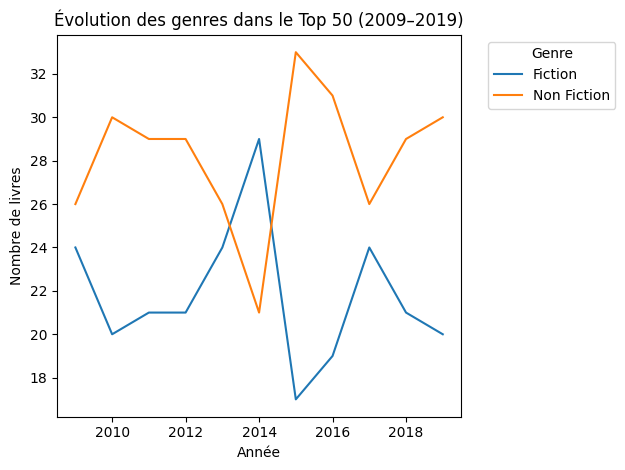

In [17]:
genre_year = df_amazon.groupby(["Year", "Genre"]).size().unstack().fillna(0)
genre_year.plot(kind='line', title="Évolution des genres dans le Top 50 (2009–2019)")
plt.xlabel("Année")
plt.ylabel("Nombre de livres")
plt.legend(title="Genre", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

# Nouvelle section

/tmp/ipykernel_311/1039738679.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="Genre", y="User Rating", data=df_amazon, palette="pastel")


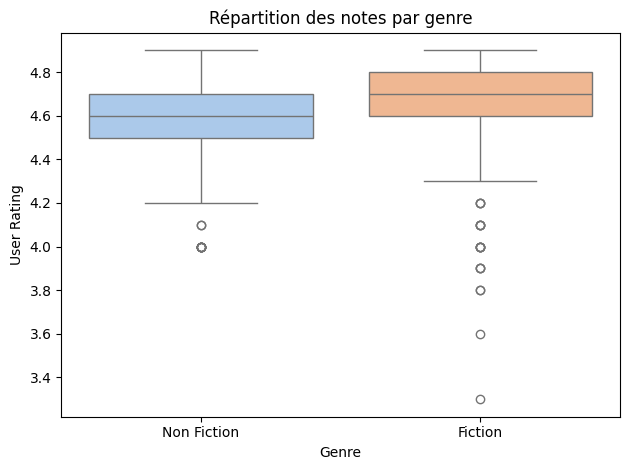

In [18]:
sns.boxplot(x="Genre", y="User Rating", data=df_amazon, palette="pastel")
plt.title("Répartition des notes par genre")
plt.tight_layout()
plt.show()

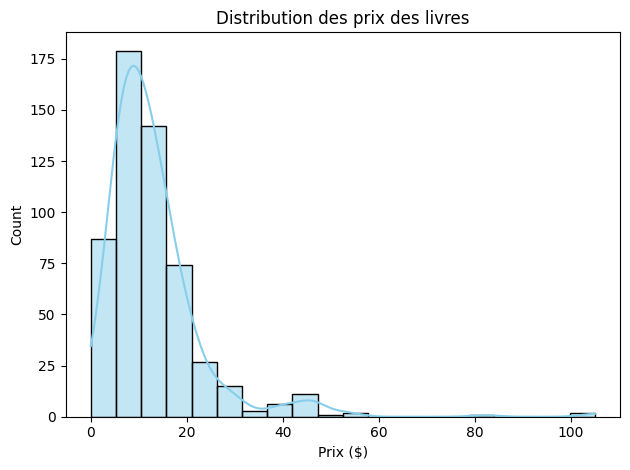

In [19]:
sns.histplot(df_amazon["Price"], bins=20, kde=True, color="skyblue")
plt.title("Distribution des prix des livres")
plt.xlabel("Prix ($)")
plt.tight_layout()
plt.show()

/tmp/ipykernel_311/2729110465.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_authors.values, y=top_authors.index, palette="viridis")


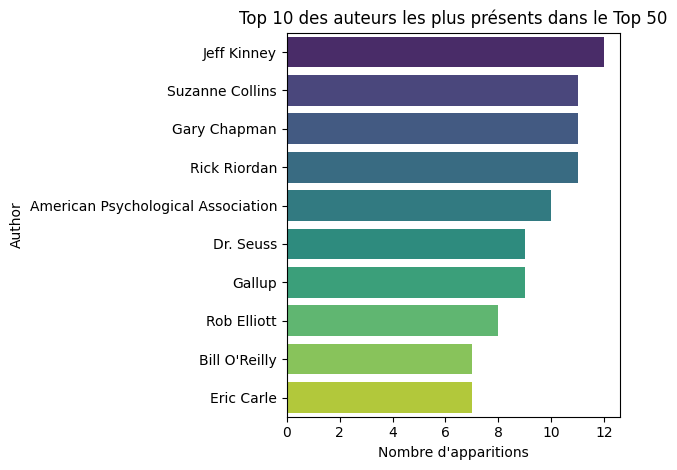

In [20]:
top_authors = df_amazon["Author"].value_counts().head(10)
sns.barplot(x=top_authors.values, y=top_authors.index, palette="viridis")
plt.title("Top 10 des auteurs les plus présents dans le Top 50")
plt.xlabel("Nombre d'apparitions")
plt.tight_layout()
plt.show()

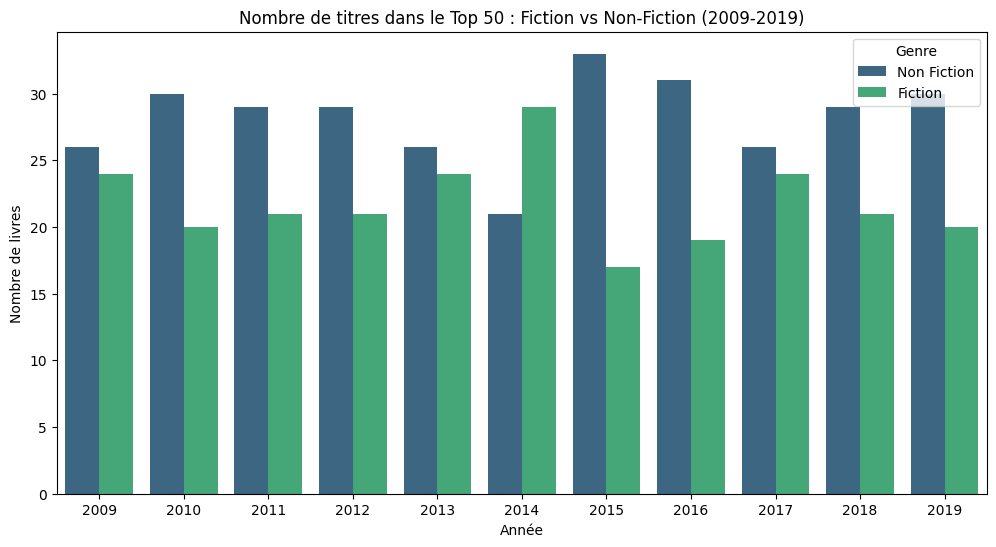

In [21]:
# --- VISUALISATION 1 : Évolution de la part de marché ---
plt.figure(figsize=(12, 6))
sns.countplot(x='Year', hue='Genre', data=df_amazon, palette='viridis')
plt.title('Nombre de titres dans le Top 50 : Fiction vs Non-Fiction (2009-2019)')
plt.ylabel('Nombre de livres')
plt.xlabel('Année')
plt.legend(title='Genre')
plt.show()

/tmp/ipykernel_311/102531743.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Genre', y='Price', data=df_unique, palette='Set2')


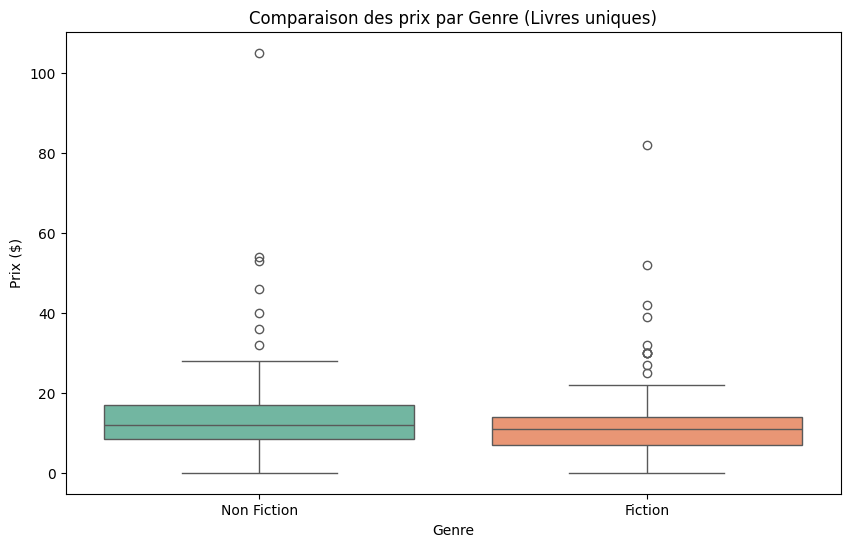

In [22]:
# --- VISUALISATION 2 : Distribution des Prix ---
plt.figure(figsize=(10, 6))
sns.boxplot(x='Genre', y='Price', data=df_unique, palette='Set2')
plt.title('Comparaison des prix par Genre (Livres uniques)')
plt.ylabel('Prix ($)')
plt.show()

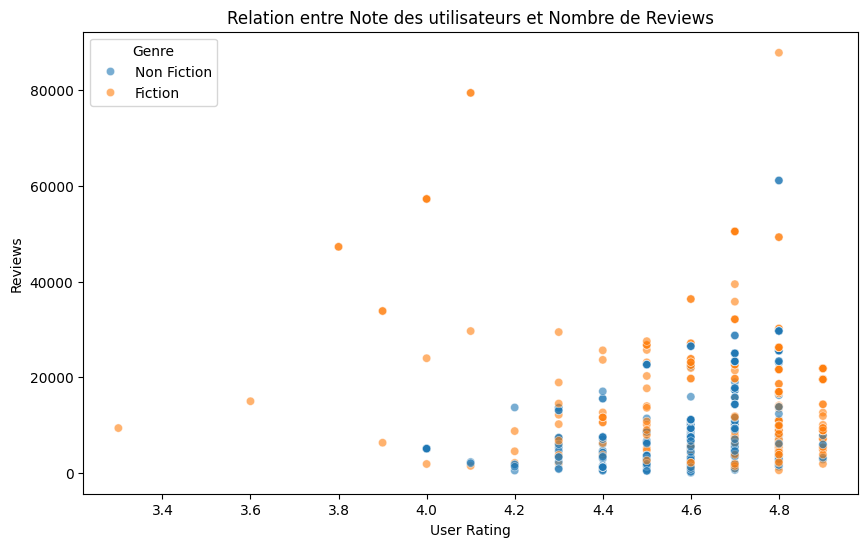

In [23]:
# --- VISUALISATION 3 : Relation Note vs Popularité ---
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_amazon, x='User Rating', y='Reviews', hue='Genre', alpha=0.6)
plt.title('Relation entre Note des utilisateurs et Nombre de Reviews')
plt.show()

In [24]:
# --- RÉSUMÉ STATISTIQUE ---
print("Statistiques moyennes par Genre :")
print(df_amazon.groupby('Genre')[['Price', 'User Rating', 'Reviews']].mean())

Statistiques moyennes par Genre :
                 Price  User Rating       Reviews
Genre                                            
Fiction      10.850000     4.648333  15683.791667
Non Fiction  14.841935     4.595161   9065.145161


In [25]:
df_amazon.to_gbq('Top_50_amazon.resultats_python', project_id='lively-sentry-460509-i0', if_exists='replace')

/tmp/ipykernel_311/2121287748.py:1: FutureWarning: to_gbq is deprecated and will be removed in a future version. Please use pandas_gbq.to_gbq instead: https://pandas-gbq.readthedocs.io/en/latest/api.html#pandas_gbq.to_gbq
  df_amazon.to_gbq('Top_50_amazon.resultats_python', project_id='lively-sentry-460509-i0', if_exists='replace')
100%|██████████| 1/1 [00:00<00:00, 8439.24it/s]


In [26]:
client = bigquery.Client(project='lively-sentry-460509-i0')

In [27]:
# Requête 1 : Évolution par année
df1 = client.query("""
    SELECT Year, Genre, COUNT(*) as Nombre_de_Titres
    FROM `top_50_amazon.Top_50_amazon`
    GROUP BY Year, Genre
    ORDER BY Year ASC
""").to_dataframe()
df1.to_gbq('Top_50_amazon.stats_par_annee', project_id='lively-sentry-460509-i0', if_exists='replace')

# Requête 2 : Top 5 par Genre
df2 = client.query("""
    SELECT Genre, Name, Author, Reviews
    FROM (
        SELECT *, RANK() OVER(PARTITION BY Genre ORDER BY Reviews DESC) as rang
        FROM `top_50_amazon.Top_50_amazon`
    ) t WHERE rang <= 5
""").to_dataframe()
df2.to_gbq('Top_50_amazon.top_5_genres', project_id='lively-sentry-460509-i0', if_exists='replace')

# Requête 3 : KPI par Genre
df3 = client.query("""
    SELECT Genre, COUNT(*) as Nombre_Apparitions, AVG(Price) as Prix_Moyen,
           AVG(`User Rating`) as Note_Moyenne, SUM(Reviews) as Total_Reviews
    FROM `top_50_amazon.Top_50_amazon`
    GROUP BY Genre
""").to_dataframe()
df3.to_gbq('Top_50_amazon.kpi_genres', project_id='lively-sentry-460509-i0', if_exists='replace')

/tmp/ipykernel_311/3980001088.py:8: FutureWarning: to_gbq is deprecated and will be removed in a future version. Please use pandas_gbq.to_gbq instead: https://pandas-gbq.readthedocs.io/en/latest/api.html#pandas_gbq.to_gbq
  df1.to_gbq('Top_50_amazon.stats_par_annee', project_id='lively-sentry-460509-i0', if_exists='replace')
100%|██████████| 1/1 [00:00<00:00, 8004.40it/s]
/tmp/ipykernel_311/3980001088.py:18: FutureWarning: to_gbq is deprecated and will be removed in a future version. Please use pandas_gbq.to_gbq instead: https://pandas-gbq.readthedocs.io/en/latest/api.html#pandas_gbq.to_gbq
  df2.to_gbq('Top_50_amazon.top_5_genres', project_id='lively-sentry-460509-i0', if_exists='replace')
100%|██████████| 1/1 [00:00<00:00, 8192.00it/s]
/tmp/ipykernel_311/3980001088.py:27: FutureWarning: to_gbq is deprecated and will be removed in a future version. Please use pandas_gbq.to_gbq instead: https://pandas-gbq.readthedocs.io/en/latest/api.html#pandas_gbq.to_gbq
  df3.to_gbq('Top_50_amazon.k